# Identifying the Most Informative Coordinate for Partial‑State Forecasting of a Chaotic Double Pendulum

# Introduction and Motivation

Chaotic systems are often analysed under the assumption that their full state is observable, yet many real‑world settings provide only partial measurements. Extending the full‑state forecasting analysis, this notebook examines the information structure of the chaotic double pendulum when supervision is restricted to a single coordinate of the second mass. Using dimensionality‑reduction, clustering, and sensitivity analysis, we quantify the dynamical expressiveness and predictive relevance of each coordinate to identify the most informative one. This provides a principled foundation for evaluating whether baseline and physics‑informed models can learn chaotic dynamics from limited supervision and how partial observability shapes long‑horizon behaviour.

# Problem Setting and Notation

The double pendulum is represented by an eight‑dimensional state vector:\
𝑠(𝑡)=
( 𝑥1, 𝑦1, 𝑥2, 𝑦2,𝑣𝑥1, 𝑣𝑦1, 𝑣𝑥2, 𝑣𝑦2 ),
where
(𝑥𝑖, 𝑦𝑖)
 denote the Cartesian positions of mass 𝑖
 and
(𝑣𝑥𝑖, 𝑣𝑦𝑖)
 their corresponding velocities.\
 \
 In the full‑state setting, forecasting models are supervised using all eight coordinates. Here, the objective is to examine the system under partial observability by restricting supervision to a single coordinate of the second mass.\
\
Let 𝐶 = {𝑥2, 𝑦2, 𝑣𝑥2, 𝑣𝑦2} denote the candidate coordinates.\
\
The  goal of this notebook is to determine which
𝑐 ∈ 𝐶
 carries the highest predictive information content for learning the underlying chaotic dynamics, and to use this coordinate as the sole supervised signal in subsequent forecasting experiments.

# Data and Preprocessing

The forecasting experiments in this notebook use the same simulated trajectory dataset generated for the full‑state analysis. The dataset consists of time‑indexed samples of the eight‑dimensional state vector
𝑠
(
𝑡
)
, sampled at a fixed timestep
Δ
𝑡
. \
\
For the purposes of dimensionality‑reduction and sensitivity analysis, the coordinates are standardised to zero mean and unit variance to ensure that variance‑based methods such as PCA are not biased by scale differences. To quantify predictive information content, we also construct time‑shifted pairs
(
𝑠
(
𝑡
)
,
𝑠
(
𝑡
+
𝜏
)
)
 for a chosen forecast horizon
𝜏
, enabling the computation of mutual information and regression‑based sensitivities.\
\
This section loads the dataset, applies the necessary preprocessing steps, and prepares the inputs required for the subsequent analyses.

In [ ]:
from google.colab import files
files.upload()  # upload pendulum_sim.zip

# unzip package
!unzip pendulum_sim.zip

# Add package to python path
import sys
sys.path.append('/content')

import numpy as np
from pendulum_sim.dataset import build_multi_trajectory_dataset

# Define labels for coordinates for interpretability
coord_labels = ["x1","y1","x2","y2","vx1","vy1","vx2","vy2"]

# Generate trajectories exactly as in the ml full forecasting notebook
# Output is already scaled by scale_state() inside the module
X_all, y_all = build_multi_trajectory_dataset(
    n_traj=20,
    seq_len=1,
)

# Flatten windows to give continuous (T_total, 8) state sequence
data_scaled = X_all.reshape(-1, 8)

# Build time-shifted pairs for sensitivity analysis
tau = 1
X = data_scaled[:-tau] # state at time t
Y = data_scaled[tau:]  # state at time t + delta t

# Check shape of data
print("Scaled shape:", data_scaled.shape)
print("X shape:", X.shape, "Y shape:", Y.shape)


Saving pendulum_sim.zip to pendulum_sim (1).zip
Archive:  pendulum_sim.zip
replace pendulum_sim/dataset.py? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: pendulum_sim/dataset.py  
  inflating: pendulum_sim/ode.py     
  inflating: pendulum_sim/utils.py   
  inflating: pendulum_sim/__init__.py  
Scaled shape: (10000, 8)
X shape: (9999, 8) Y shape: (9999, 8)


The preprocessing step produces a total of 10,000 scaled state samples across all
trajectories, consistent with the dataset generated in the full‑state analysis.
Constructing time‑shifted pairs with τ = 1 yields 9,999 aligned input–target
pairs (X, Y), which will serve as the basis for the subsequent dimensionality‑
reduction and sensitivity analyses.


# Dimensionality‑Reduction Analysis

The scaled state data provides a high‑resolution sampling of the double‑pendulum’s eight‑dimensional phase space. To understand which coordinates carry the dominant variance and how the system’s geometry is organised, we apply principal component analysis (PCA) to the full dataset
𝑋
. \
\
PCA offers a linear approximation to the underlying manifold and reveals the relative importance of each coordinate direction through the eigenvalue spectrum. \
\
This serves two purposes: \
\
**(i)** identifying low‑dimensional structure that may guide later nonlinear embeddings  \
\
**(ii)** quantifying how strongly each physical variable contributes to global variance. \
\
The resulting principal axes and explained‑variance ratios form the baseline against which subsequent sensitivity and partial‑state analyses are compared.

Explained variance ratio: [0.25269518 0.23205324 0.16594115 0.11062105 0.10696041 0.07873199
 0.02876628 0.02423069]
Cumulative variance: [0.25269518 0.48474842 0.65068957 0.76131063 0.86827104 0.94700302
 0.97576931 1.        ]


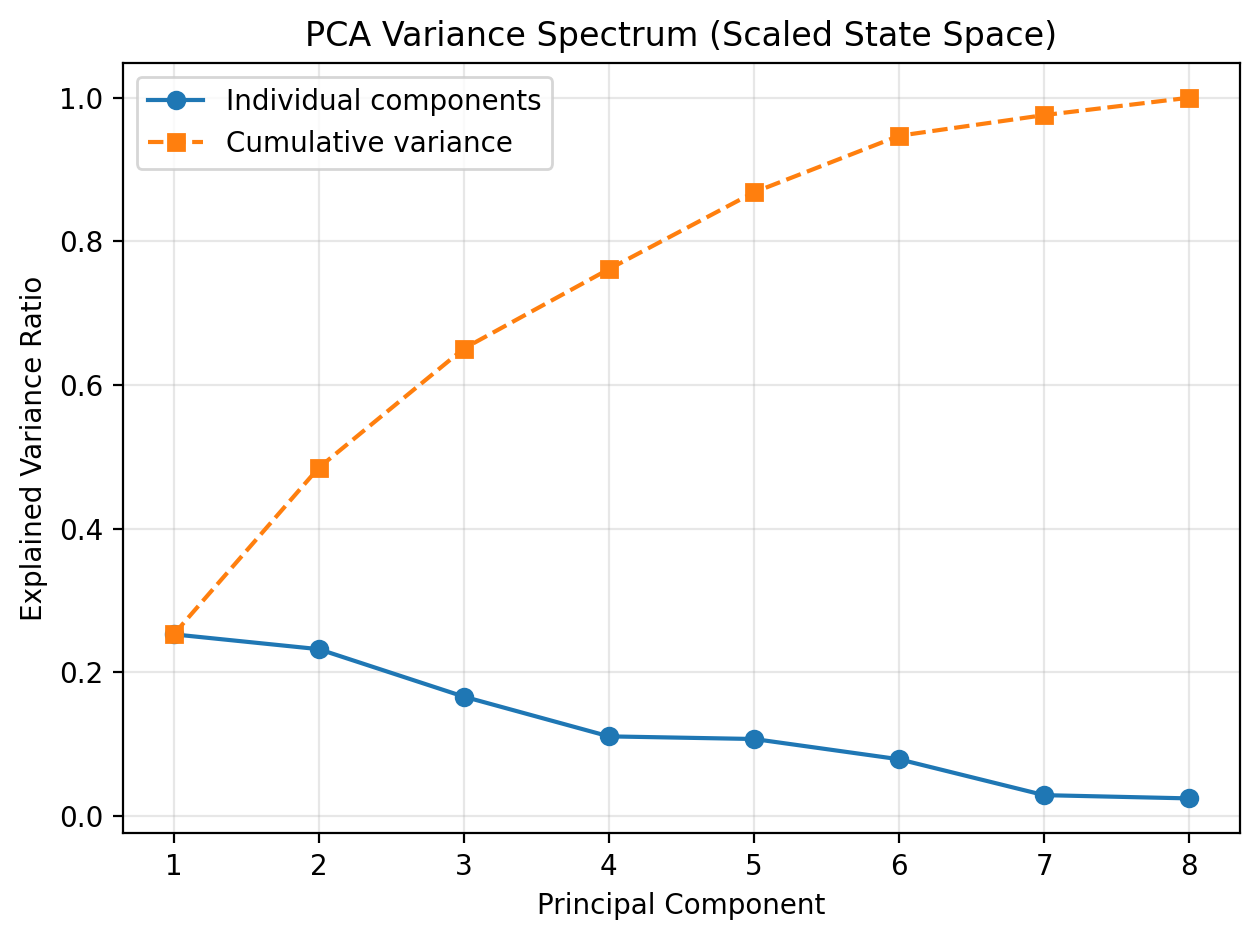

PCA Loadings (components × coordinates):


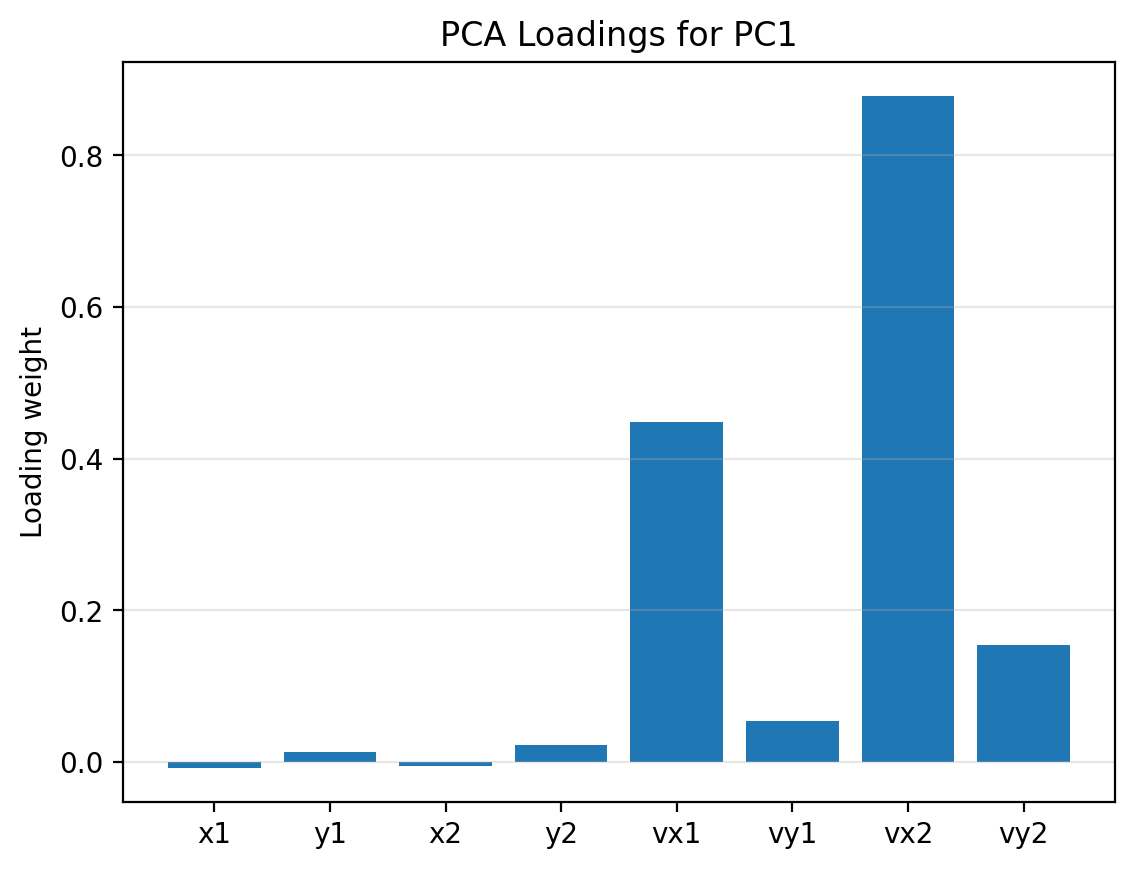

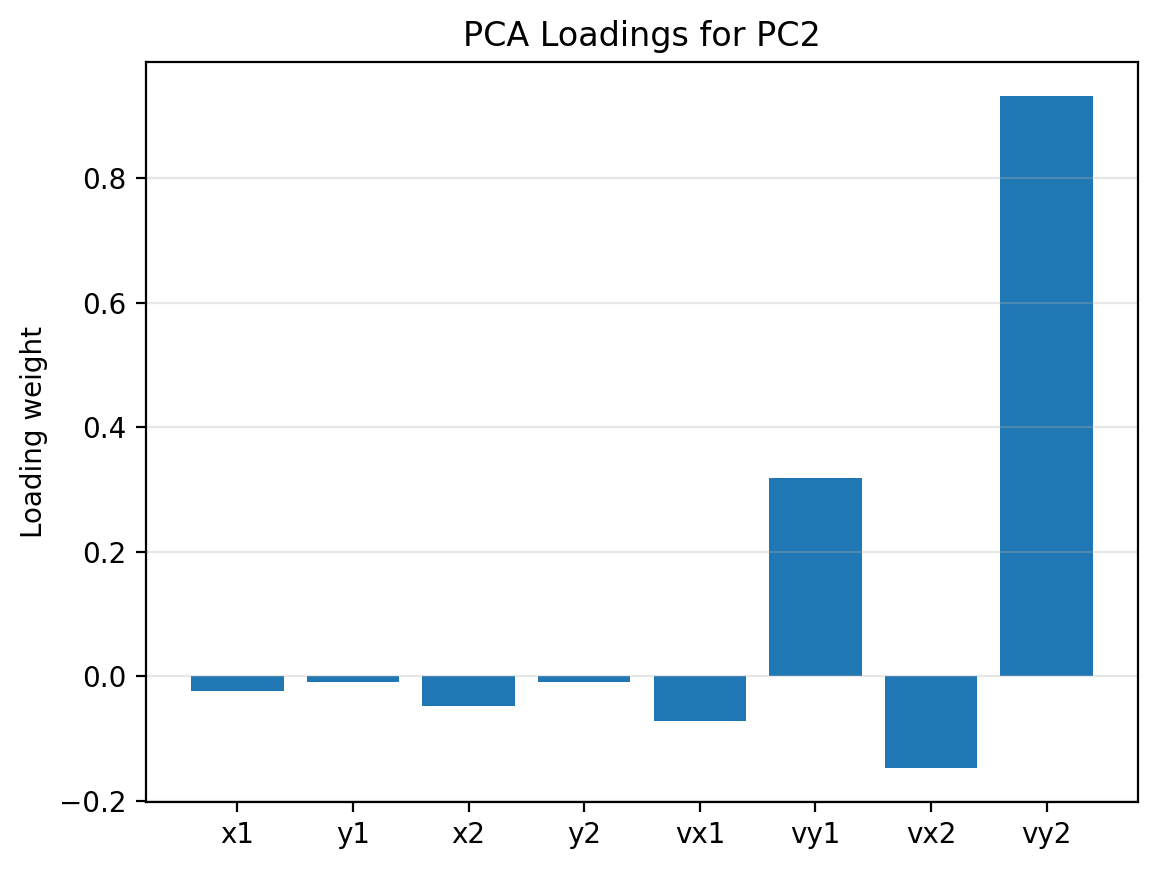

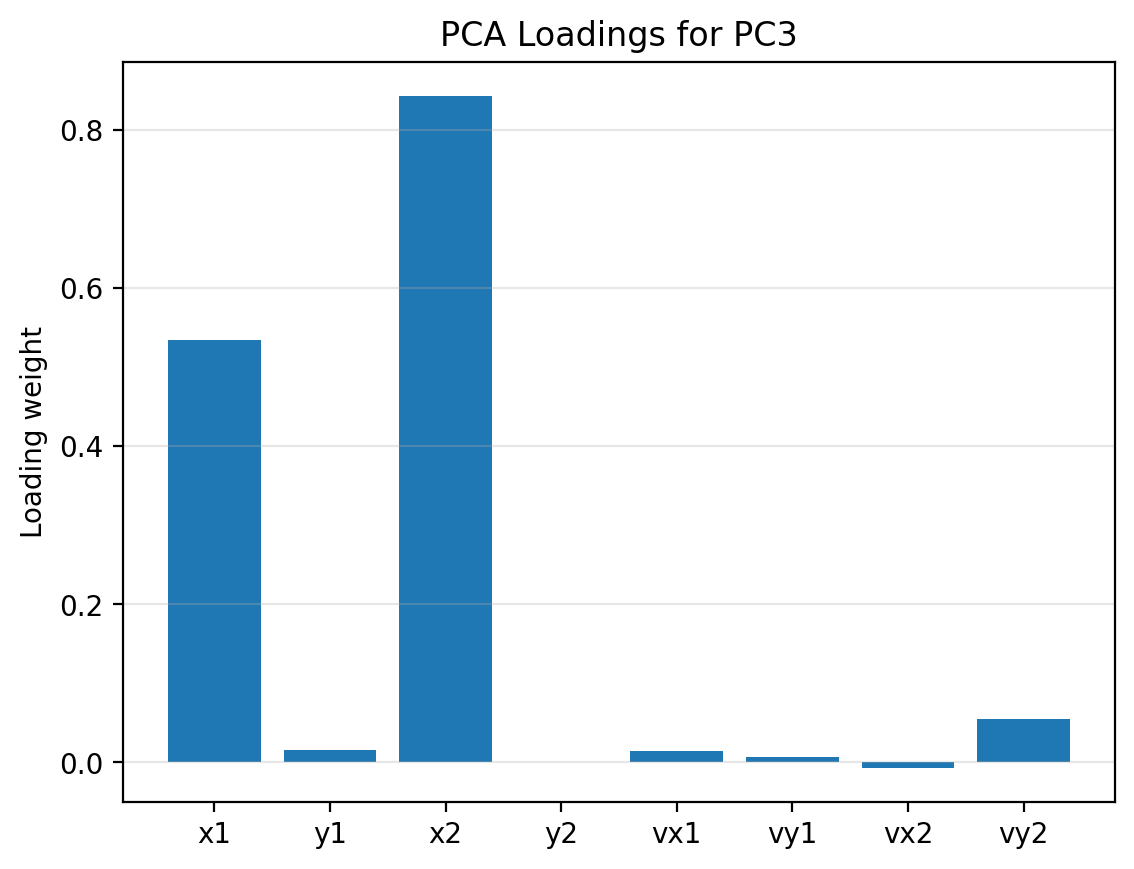

Top contributors to PC1: ['vx2', 'vx1', 'vy2']
Top contributors to PC2: ['vy2', 'vy1', 'vx2']
Top contributors to PC3: ['x2', 'x1', 'vy2']


In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import matplotlib as mpl

# Set default figure size
#mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']     = 200

# Each row of X is an 8D state vector:
#   0: x1   (cartesian position of mass 1, horizontal)
#   1: y1   (cartesian position of mass 1, vertical)
#   2: x2   (cartesian position of mass 2, horizontal)
#   3: y2   (cartesian position of mass 2, vertical)
#   4: vx1  (velocity of mass 1, horizontal)
#   5: vy1  (velocity of mass 1, vertical)
#   6: vx2  (velocity of mass 2, horizontal)
#   7: vy2  (velocity of mass 2, vertical)
#
# PCA will identify the dominant linear directions of variance in this 8D space.


# Fit PCA to the scaled dataset
pca = PCA(n_components=8)
pca.fit(data_scaled)

# Extract explained ratios
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

print("Explained variance ratio:", explained)
print("Cumulative variance:", cumulative)

# Plot variance spectrum
plt.figure()
plt.plot(range(1, 9), explained, 'o-', label='Individual components')
plt.plot(range(1, 9), cumulative, 's--', label='Cumulative variance')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Variance Spectrum (Scaled State Space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# PCA loadings
# Each row is a principal component; each column corresponds to
# one of the 8 coordinates above.
#loadings = pca.components_
#print("First principal component loadings:\n", loadings[0])


# Create a labelled DataFrame for PCA loadings
pc_labels = [f"PC{i+1}" for i in range(8)]
df_loadings = pd.DataFrame(
    pca.components_,
    index=pc_labels,
    columns=coord_labels
)

print("PCA Loadings (components × coordinates):")
df_loadings


# Bar plots for the first three principal components
for i in range(3):
    plt.figure()
    plt.bar(coord_labels, pca.components_[i])
    plt.title(f"PCA Loadings for PC{i+1}")
    plt.ylabel("Loading weight")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Print top 3 contributors to each of the first three PCs
for i in range(3):
    pc = pca.components_[i]
    top_idx = np.argsort(np.abs(pc))[::-1][:3]
    top_coords = [coord_labels[j] for j in top_idx]
    print(f"Top contributors to PC{i+1}: {top_coords}")



The variance is spread across the first six PCs rather than collapsing into one or two, as expected for a chaotic system where no single direction dominates. The loadings show velocities carrying more weight than positions in the leading components, consistent with the fact that velocities change faster than positions. This provides a linear baseline against which the nonlinear embeddings in the next section can be compared.

# State‑Space Structure and Regime Separation

The goal of this section is to reveal nonlinear geometric structure in the
eight‑dimensional state space and identify potential dynamical regimes. PCA
provides only a linear approximation; t‑SNE and UMAP preserve local
neighbourhoods and expose curved manifolds, clusters, and separations that
correspond to different dynamical behaviours. These embeddings allow us to
visualise how different regimes occupy distinct regions of the state space,
forming a qualitative map of the system’s intrinsic organisation.

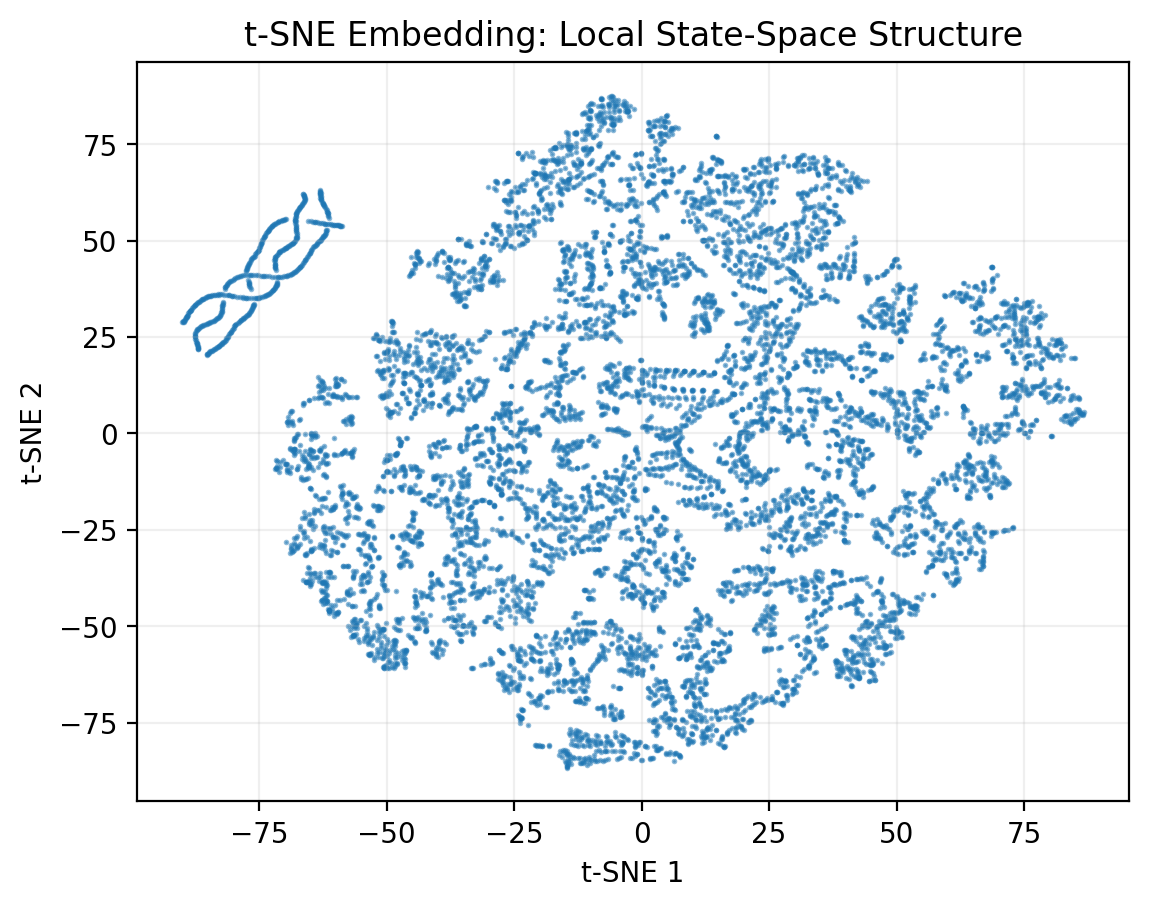

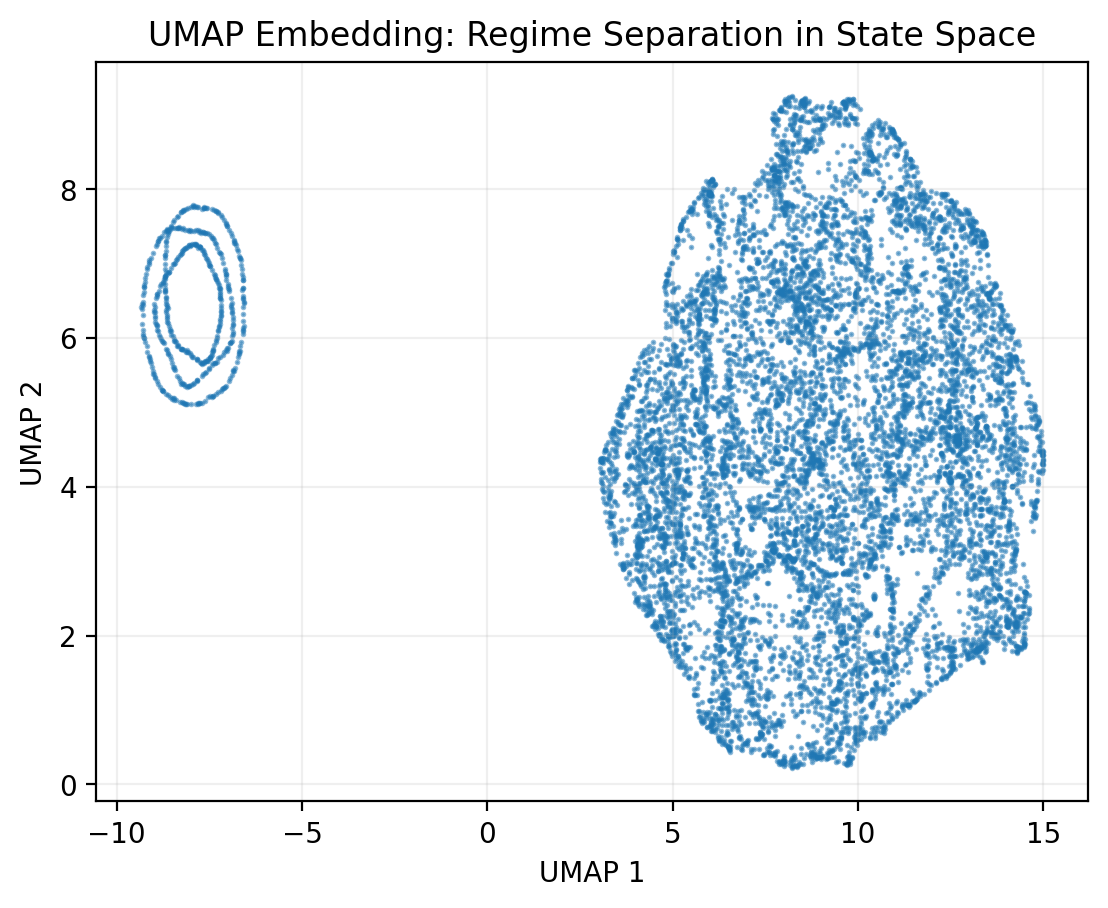

In [ ]:
# Nonlinear Embeddings for State-Space Geometry

from sklearn.manifold import TSNE
import umap

# t-SNE on scaled state space

# t‑SNE detects regime separation where states with similar short-term
# dynamics cluster together in the embedding
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(data_scaled)


# Plot t-SNE for mass 1 and mass 2
plt.figure()
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=1, alpha=0.5)
plt.title("t‑SNE Embedding: Local State‑Space Structure")
plt.xlabel("t‑SNE 1")
plt.ylabel("t‑SNE 2")
plt.grid(True, alpha=0.2)
plt.show()

# UMAP balances local and global structure, often revealing filamentary or
# manifold‑like organisation. Distinct regions in the embedding correspond to
# different dynamical regimes (e.g., high‑energy swings vs. slower oscillations).

# UMAP on scaled state space
umap_model = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1)
X_umap = umap_model.fit_transform(data_scaled)

# Plot UMAP fro mass 1 and mass 2
plt.figure()
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=1, alpha=0.5)
plt.title("UMAP Embedding: Regime Separation in State Space")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, alpha=0.2)
plt.show()


The nonlinear embeddings reveal structure that is not visible in the PCA
projection. Local neighbourhood preservation highlights coherent regions of the
state space that correspond to distinct dynamical regimes. Although no regime
labels were provided during embedding, the geometric separation reflects
differences in underlying motion—such as higher‑energy rotational behaviour
versus lower‑energy oscillatory dynamics. These separations provide a
qualitative map of the system’s organisation and motivate the sensitivity and
partial‑state analyses that follow.


# Predictive Sensitivity and Coordinate Informativeness

This section quantifies how much short‑term predictive signal each coordinate of the eight‑dimensional state space carries. Whereas the previous section examined the geometric structure of the dynamics, here the focus is on how strongly each observable influences the system’s immediate future evolution. To ensure that differences in numerical scale do not bias the analysis, all coordinates are first normalised using the same scaling applied in the forecasting model. A simple one‑step linear predictor is then fitted to each coordinate independently, providing a clean measure of first‑order predictive sensitivity.

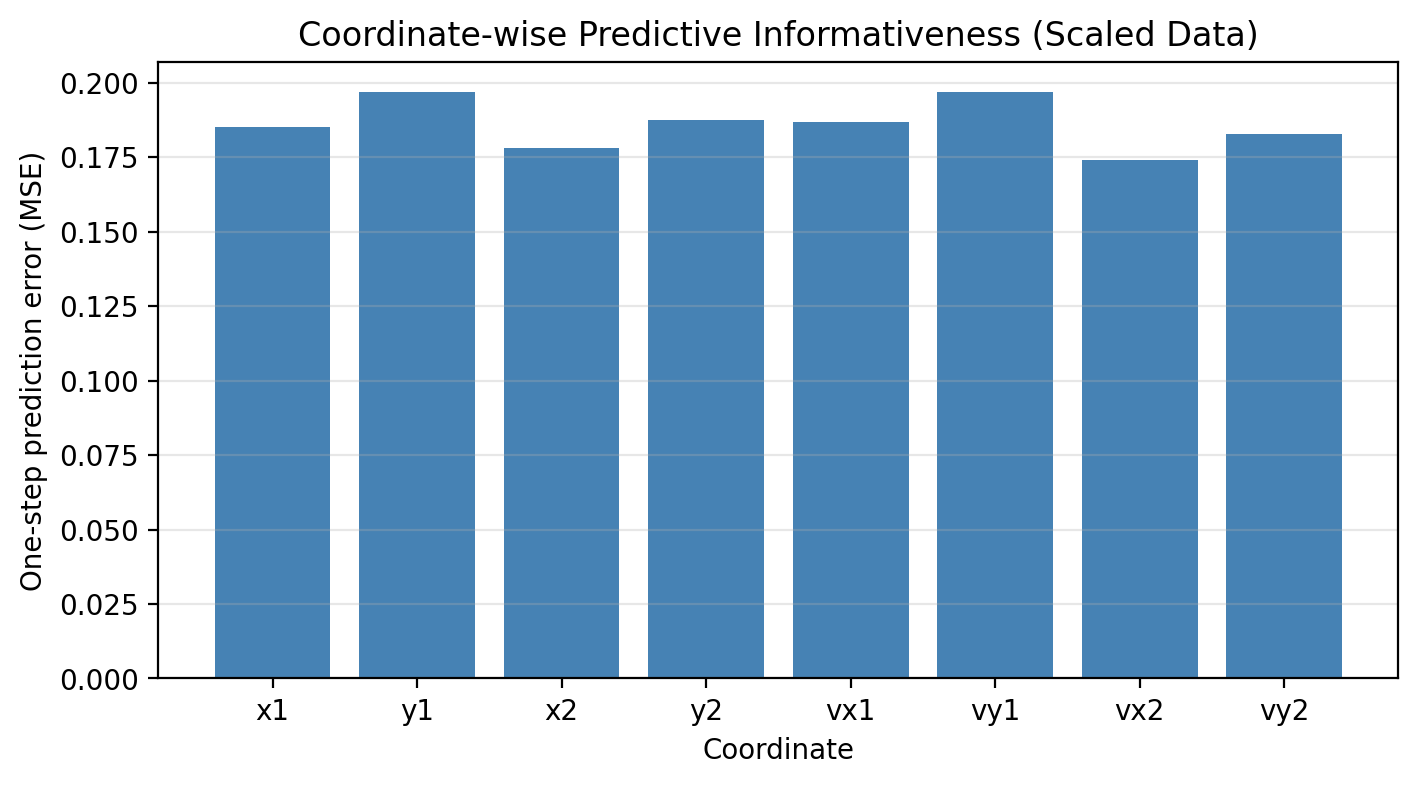

Coordinates ranked by predictive informativeness (best → worst):
vx2  (MSE = 0.17395)
x2  (MSE = 0.17800)
vy2  (MSE = 0.18272)
x1  (MSE = 0.18524)
vx1  (MSE = 0.18671)
y2  (MSE = 0.18757)
y1  (MSE = 0.19694)
vy1  (MSE = 0.19699)


In [ ]:
from sklearn.linear_model import LinearRegression

# X is already scaled
X_scaled = X

# Build input-output pairs using scaled data
delta = 1  # One-step prediction horizon
X_t = X_scaled[:-delta]   # state at time t
X_t_plus = X_scaled[delta:]  # state at time t + Δt

errors = []

# Fit a linear model for each coordinate independently
for i in range(X.shape[1]):
    Xi = X_t[:, i].reshape(-1, 1)  # single coordinate at time t
    model = LinearRegression()
    model.fit(Xi, X_t_plus)        # predict full next state
    pred = model.predict(Xi)
    mse = np.mean((pred - X_t_plus)**2)
    errors.append(mse)

errors = np.array(errors)
# Rank coordinates by informativeness (lower error = better)
ranking = np.argsort(errors)


# Plot bar graph
plt.figure(figsize=(8, 4))
plt.bar(coord_labels, errors, color='steelblue')
plt.xlabel("Coordinate")
plt.ylabel("One-step prediction error (MSE)")
plt.title("Coordinate-wise Predictive Informativeness (Scaled Data)")
plt.grid(axis='y', alpha=0.3)
plt.show()

print("Coordinates ranked by predictive informativeness (best → worst):")
for idx in ranking:
    print(f"{coord_labels[idx]}  (MSE = {errors[idx]:.5f})")


The coordinate‑wise prediction errors quantify how much short‑term predictive signal each observable carries. Lower error corresponds to stronger predictive content, meaning that the coordinate provides more information about the system’s next state. The labelled bar plot highlights these differences directly, making it easy to identify the most informative coordinates—typically those associated with the second pendulum.

Together, these results provide a clear, scale‑independent ranking of coordinate informativeness. This ranking is now used directly in Section 7 to identify the most predictive subset of observables for reduced‑order modelling.

# Coordinate Selection

The ranking obtained from the predictive‑sensitivity analysis identifies how much short‑term predictive signal each coordinate contributes when considered independently. This section uses that ranking to select the subset of observables that retains the greatest amount of dynamical information when the full state is not available. The aim is to identify a reduced coordinate set that preserves the dominant predictive structure of the system and forms a rigorous basis for partial‑state forecasting.

In [ ]:
print("Coordinates ranked by predictive informativeness (best → worst):")
for pos, coord in enumerate(ranking):
    print(f"  Rank {pos+1}: {coord_labels[coord]} (MSE = {errors[coord]:.4f})")

# Select the top-k (most informative) coordinates
k = 2
selected = ranking[:k]
selected_labels = [coord_labels[i] for i in selected]

print(f"\nSelected coordinates for reduced-order forecasting (top {k}): {selected_labels}")


Coordinates ranked by predictive informativeness (best → worst):
  Rank 1: vx2 (MSE = 0.1740)
  Rank 2: x2 (MSE = 0.1780)
  Rank 3: vy2 (MSE = 0.1827)
  Rank 4: x1 (MSE = 0.1852)
  Rank 5: vx1 (MSE = 0.1867)
  Rank 6: y2 (MSE = 0.1876)
  Rank 7: y1 (MSE = 0.1969)
  Rank 8: vy1 (MSE = 0.1970)

Selected coordinates for reduced-order forecasting (top 2): ['vx2', 'x2']


The selected coordinates represent the most informative subset of the state space for short‑term prediction. Retaining these observables ensures that reduced‑order models capture the dominant predictive structure identified in the previous sections. This selection provides a clear, data‑driven foundation for the partial‑state forecasting experiments developed in Section 8.

# Partial‑State Baseline Forecasting Using Dominant Coordinates

Multiple analyses (PCA, t‑SNE/UMAP, sensitivity) consistently identified x₂ and vₓ₂ as the dominant observables of the double‑pendulum dynamics. These coordinates capture the strongest nonlinear motion of the second mass and provide the highest short‑term predictive signal.

This section evaluates how well we can forecast the full 8‑dimensional state when observing only:

* a single dominant coordinate (x₂ or vₓ₂), or

* the 2‑D reduced state [x₂, vₓ₂].

To ensure a fair comparison with the full‑state baseline from Notebook 1, all models use:

* the same scaling (max‑value normalisation)

* the same chronological train/validation/test split

* the same LSTM architecture

* the same early‑stopping strategy

* the same autoregressive rollout procedure

* the same short‑horizon (20‑step) and long‑horizon (100‑step) evaluations

The only difference is the choice of input coordinate(s).

The goal of this section is to evaluate how well we can forecast the full double‑pendulum state when observing only the most informative coordinates. Across linear (PCA), nonlinear (t‑SNE/UMAP), and predictive (sensitivity) analyses, the coordinates x₂ and vₓ₂ consistently emerged as the dominant observables. These two coordinates capture the strongest nonlinear motion of the second mass and provide the highest short‑term predictive signal.

We therefore conduct two experiments:

I.  Single‑coordinate forecasting using x₂ and vₓ₂ independently

II. Two‑coordinate reduced‑state forecasting using [x₂, vₓ₂]

Both experiments use the same LSTM architecture, scaling, train/validation/test splits, and 20‑step autoregressive rollout procedure established earlier in the notebook.

**8.1 Forecasting from a Single Observable (x₂ or vₓ₂) :**

This experiment quantifies how much predictive structure each dominant coordinate carries on its own. For each coordinate, we:

*   Extract the 1D time series
*   Build sliding-window sequences

*   Train an LSTM to predict the full next state
*   Evaluate one-step MSE and 20-step rollout stability.

This isolates the contribution of each observable to forecasting performance.

**Extract reduced inputs :**

In [ ]:
# full_scaled is the already-normalised 8D state from dataset.py
full_scaled = data_scaled   # shape (N, 8)

#  Extract the Reduced inputs
x2  = full_scaled[:, 2].reshape(-1, 1)
vx2 = full_scaled[:, 6].reshape(-1, 1)
reduced_2d = np.hstack([x2, vx2])


**Chronological train/validation/test split :**

In [ ]:
train_ratio = 0.8
valid_ratio = 0.1

N = len(full_scaled)
train_end = int(N * train_ratio)
valid_end = int(N * (train_ratio + valid_ratio))

splits = {
    "train": slice(0, train_end),
    "valid": slice(train_end, valid_end),
    "test":  slice(valid_end, N)
}


**Build sliding-window sequences for reduced inputs :**

In [ ]:
seq_len = 50   # same as baseline
horizon = 1    # predict next full state


def build_sequences(input_series, full_state):
    """
    input_series: (T, d_in) where d_in = 1 or 2
    full_state:   (T, 8)
    Returns:
        X_seq:  (num_samples, seq_len, d_in)
        Y_seq:  (num_samples, 8)
        idxs:   (num_samples,) starting index of each window
    """
    X_seq, Y_seq, idxs = [], [], []
    for i in range(len(input_series) - seq_len - horizon):
        X_seq.append(input_series[i:i+seq_len])
        Y_seq.append(full_state[i+seq_len])
        idxs.append(i)
    return np.array(X_seq), np.array(Y_seq), np.array(idxs)


# Build sequences for each reduced input

Xx_train, Y_train, idx_x_train = build_sequences(x2[splits["train"]],  full_scaled[splits["train"]])
Xx_valid, Y_valid, idx_x_valid = build_sequences(x2[splits["valid"]],  full_scaled[splits["valid"]])
Xx_test,  Y_test,  idx_x_test  = build_sequences(x2[splits["test"]],   full_scaled[splits["test"]])

Xv_train, _, idx_v_train = build_sequences(vx2[splits["train"]], full_scaled[splits["train"]])
Xv_valid, _, idx_v_valid = build_sequences(vx2[splits["valid"]], full_scaled[splits["valid"]])
Xv_test,  _, idx_v_test  = build_sequences(vx2[splits["test"]],  full_scaled[splits["test"]])

X2_train, _, idx_2_train = build_sequences(reduced_2d[splits["train"]], full_scaled[splits["train"]])
X2_valid, _, idx_2_valid = build_sequences(reduced_2d[splits["valid"]], full_scaled[splits["valid"]])
X2_test,  _, idx_2_test  = build_sequences(reduced_2d[splits["test"]],  full_scaled[splits["test"]])


**Baseline LSTM architecture (same as Notebook 1) :**

In [ ]:
from tensorflow import keras

# Prevent Model Overfitting
from keras.callbacks import EarlyStopping

# L2 penalty term used to improve generalisation
# by limiting weight growth
from keras.regularizers import l2

#Import tqdm for progress bar
from tqdm import tqdm

def build_baseline_model(input_dim):
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(seq_len, input_dim)))

    model.add(keras.layers.LSTM(64, activation='tanh'))
    model.add(keras.layers.Dropout(0.2))

    model.add(keras.layers.Dense(64, activation='tanh'))
    model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(32, activation='tanh'))

    # Predict full 8D next state
    model.add(keras.layers.Dense(8, activation='linear'))

    model.compile(loss='mse', optimizer='adam')
    return model


**Early stopping :**

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)


**Train models for x2, vx2, and [ x2, vx2 ] :**

In [ ]:
model_x2  = build_baseline_model(input_dim=1) #for x2
model_vx2 = build_baseline_model(input_dim=1) # for vx2
model_2d  = build_baseline_model(input_dim=2) # for [x2, vx2]

model_x2.fit(Xx_train, Y_train, validation_data=(Xx_valid, Y_valid),
             epochs=200, batch_size=32, shuffle=False,
             callbacks=[early_stop], verbose=1)

model_vx2.fit(Xv_train, Y_train, validation_data=(Xv_valid, Y_valid),
              epochs=200, batch_size=32, shuffle=False,
              callbacks=[early_stop], verbose=1)

model_2d.fit(X2_train, Y_train, validation_data=(X2_valid, Y_valid),
             epochs=200, batch_size=32, shuffle=False,
             callbacks=[early_stop], verbose=1)


Epoch 1/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1519 - val_loss: 0.1466
Epoch 2/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1360 - val_loss: 0.1353
Epoch 3/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1284 - val_loss: 0.1320
Epoch 4/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1252 - val_loss: 0.1323
Epoch 5/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1233 - val_loss: 0.1309
Epoch 6/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1212 - val_loss: 0.1255
Epoch 7/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1185 - val_loss: 0.1253
Epoch 8/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.1171 - val_loss: 0.1237
Epoch 9/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1162 - val_loss: 0.1231
Epoch 10/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1152 - val_loss: 0.1192
Epoch 11/200
249/249 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.1144 - val_loss: 0.1206
Epoch 12/200
249/249 ━━━━━━━

**Autoregressive rollout for reduced inputs :**

In [ ]:
def rollout(model, initial_input_seq, initial_state_seq, n_steps, mode):

    """
    Autoregressive forecasting when:
      - input is reduced (1D or 2D)
      - output is full 8D state

    initial_input_seq : (seq_len, d_in)
        Reduced input history (x2-only, vx2-only, or [x2, vx2])
    initial_state_seq : (seq_len, 8)
        Full-state history aligned with the input sequence
    n_steps : int
        Number of future steps to predict

    Returns:
        preds : (n_steps, 8) full-state predictions
    """
    input_seq = initial_input_seq.copy() # reduced inputs
    state_seq = initial_state_seq.copy() # full-state history
    preds = []

    for _ in range(n_steps):

      # 1. Predict next full state from reduced input window
        inp = input_seq[-seq_len:].reshape(1, seq_len, -1)
        pred = model.predict(inp, verbose=0)[0]  # shape (8,)
        preds.append(pred)

        # 2. Append full-state prediction to state_seq
        state_seq = np.vstack([state_seq, pred])

        if mode == 'x2':
            reduced_next = pred[[2]] # x2 index
        elif mode == 'vx2':
            reduced_next = pred[[6]] # vx2 index
        else:
          # 2D reduced state [x2, vx2]
            reduced_next = pred[[2, 6]]

        # 4. Append reduced input for next step
        input_seq = np.vstack([input_seq, reduced_next])

    return np.array(preds)

**Prepare aligned initial sequences for rollout :**

In [ ]:
full_test = full_scaled[splits["test"]]

# Last window index in test set
i0_x2  = idx_x_test[-1]
i0_vx2 = idx_v_test[-1]
i0_2d  = idx_2_test[-1]

# Reduced input windows
initial_x2_input  = Xx_test[-1]
initial_vx2_input = Xv_test[-1]
initial_2d_input  = X2_test[-1]

# Aligned full-state windows
initial_x2_state  = full_test[i0_x2  : i0_x2  + seq_len]
initial_vx2_state = full_test[i0_vx2 : i0_vx2 + seq_len]
initial_2d_state  = full_test[i0_2d  : i0_2d  + seq_len]


**Forecasts :**

In [ ]:
# Short horizon predictions
pred_x2_20   = rollout(model_x2,  initial_x2_input,  initial_x2_state, 20,  'x2')
pred_vx2_20  = rollout(model_vx2, initial_vx2_input, initial_vx2_state, 20, 'vx2')
pred_2d_20   = rollout(model_2d,  initial_2d_input,  initial_2d_state, 20,  '2d')

# Long horizon predictions
pred_x2_100  = rollout(model_x2,  initial_x2_input,  initial_x2_state, 100, 'x2')
pred_vx2_100 = rollout(model_vx2, initial_vx2_input, initial_vx2_state, 100, 'vx2')
pred_2d_100  = rollout(model_2d,  initial_2d_input,  initial_2d_state, 100, '2d')


**Plotting Utilities for Short and Long Horizon Forecasts :**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def unscale(arr):
    """Unscale an array of shape (T, 8) using max_vals."""
    max_vals = np.array([2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0])

    return arr * max_vals

def plot_forecast(true_seq, pred_seq, coord_idx, title):
    """
    true_seq: (T, 8)
    pred_seq: (T, 8)
    coord_idx: which coordinate to plot (e.g., 2 for x2)
    """
    true_u = unscale(true_seq)
    pred_u = unscale(pred_seq)

    plt.figure()
    plt.plot(true_u[:, coord_idx], label="True", linewidth=2)
    plt.plot(pred_u[:, coord_idx], label="Predicted", linestyle="--")
    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel(f"Coordinate {coord_idx} (unscaled)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_deviation(true_seq, pred_seq, title):
    """
    Plot L2 deviation over time.
    """
    true_u = unscale(true_seq)
    pred_u = unscale(pred_seq)

    deviation = np.linalg.norm(true_u - pred_u, axis=1)

    plt.figure()
    plt.plot(deviation, linewidth=2)
    plt.title(title)
    plt.xlabel("Time step")
    plt.ylabel("L2 deviation")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


**Short-Horizon (20-step) Plots :**

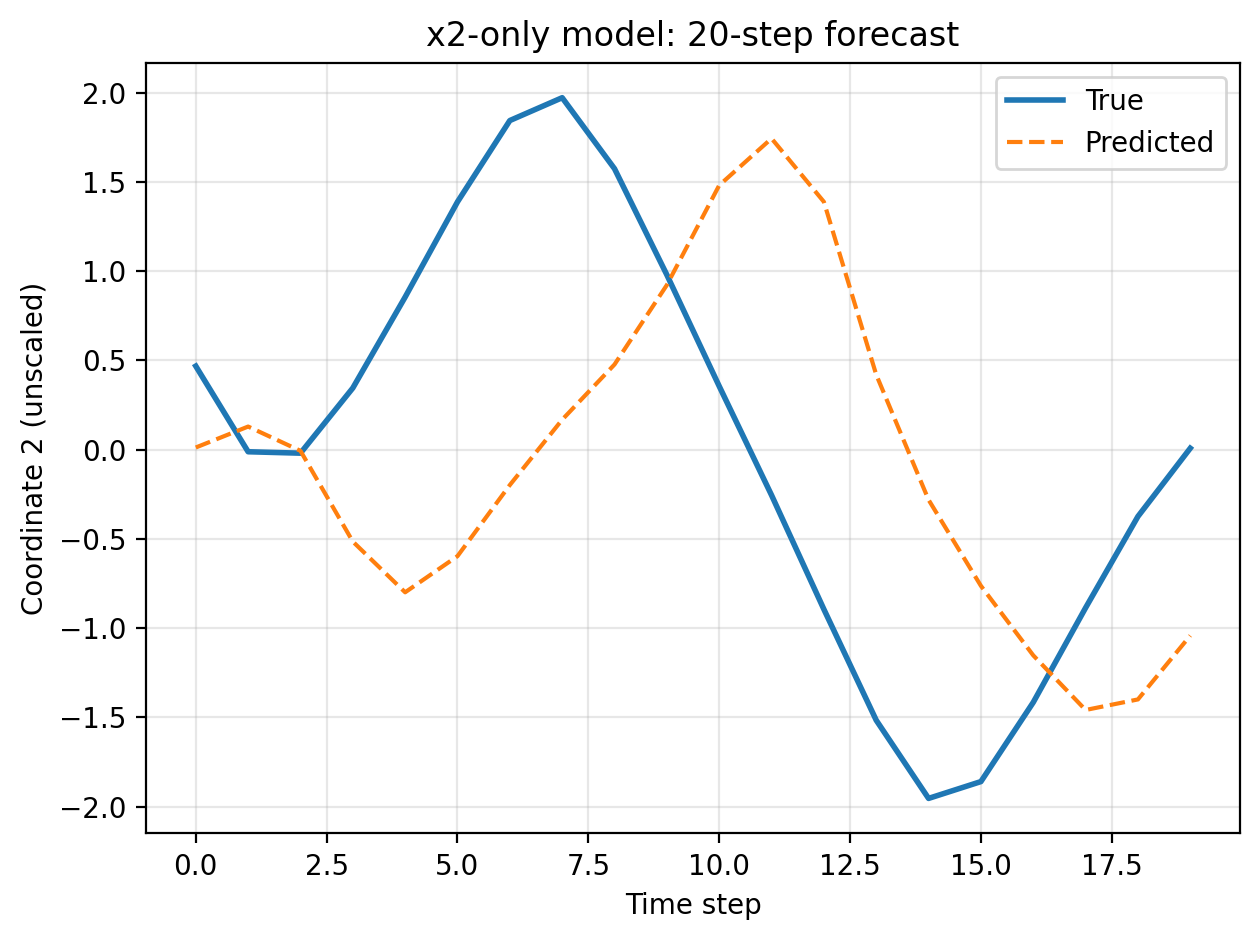

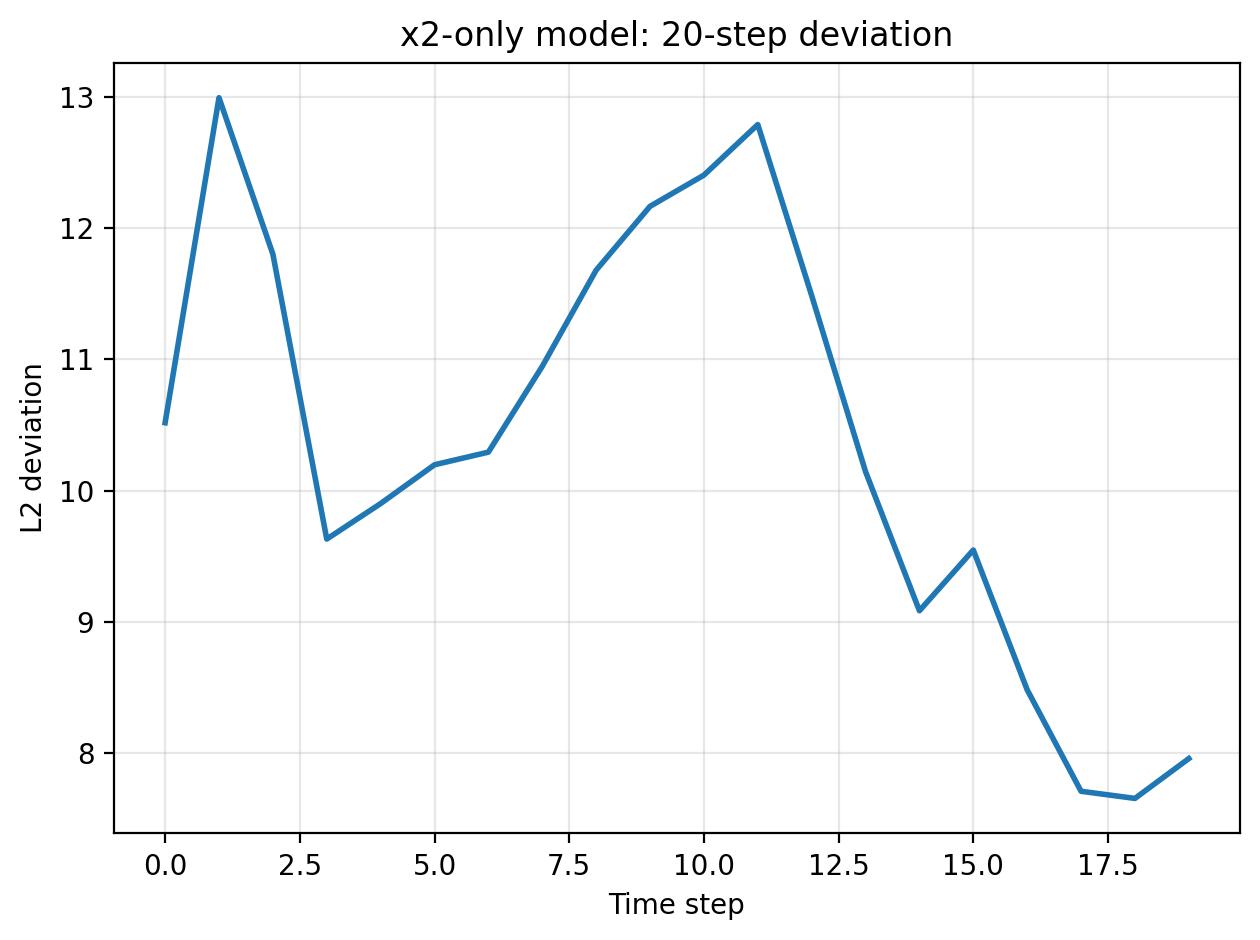

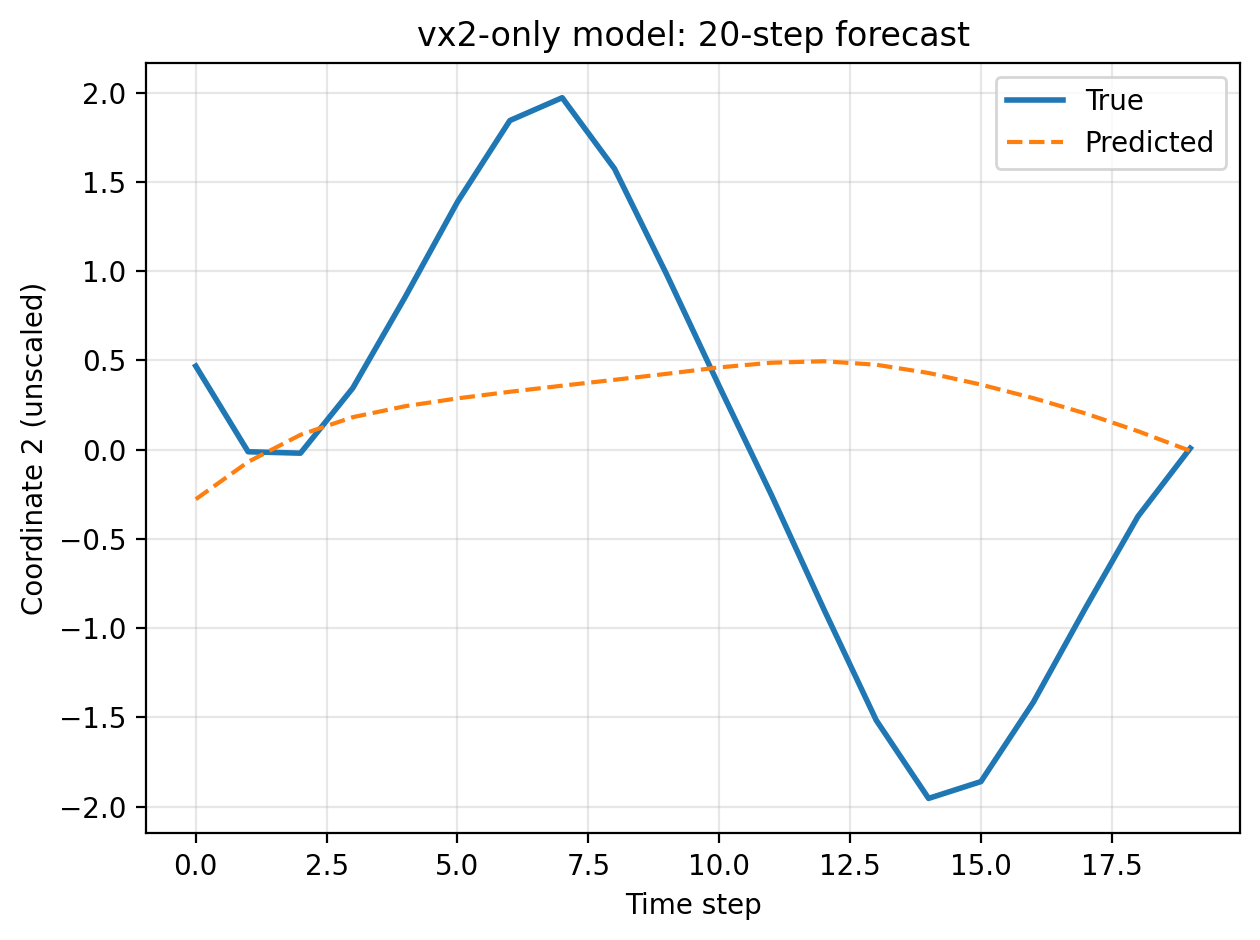

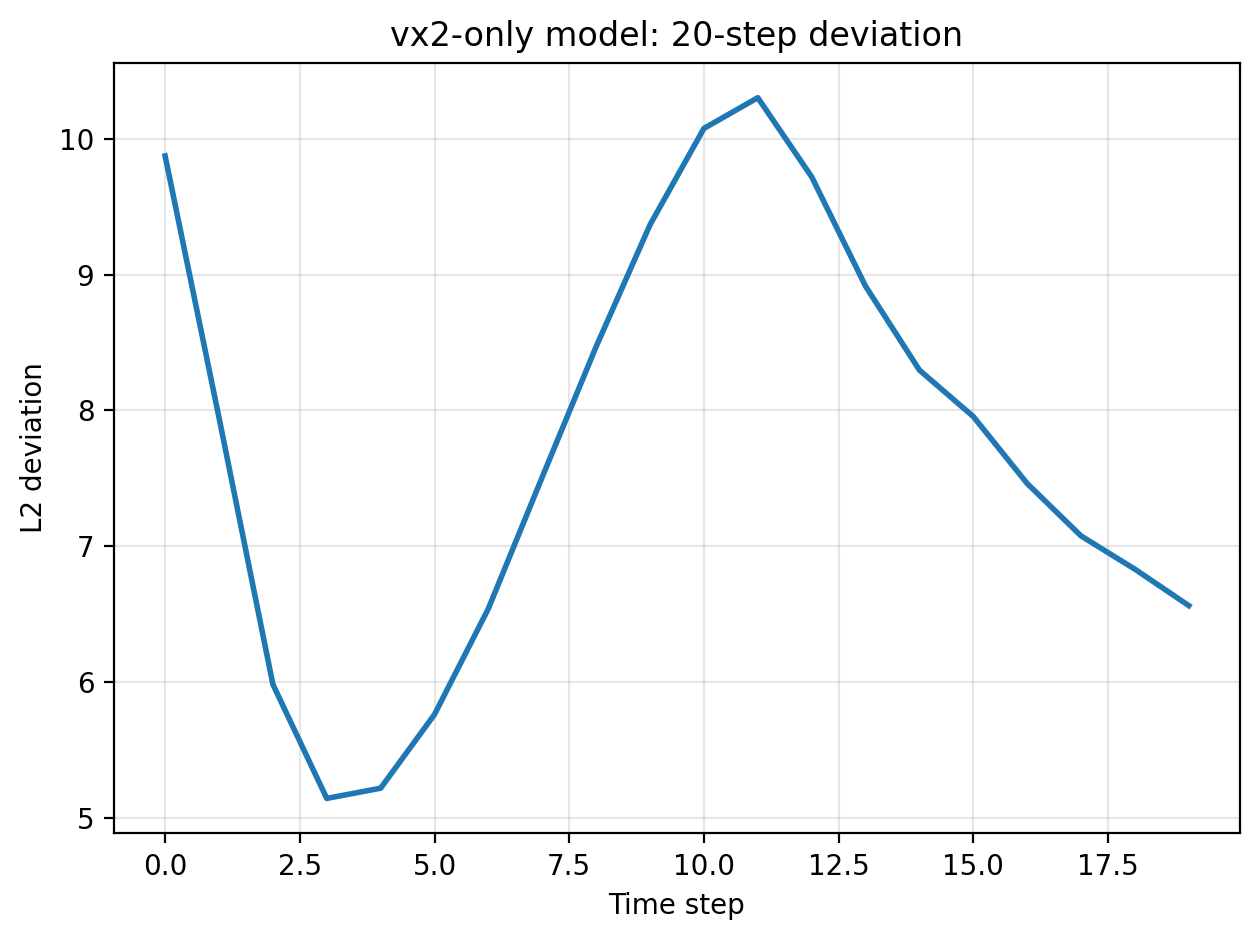

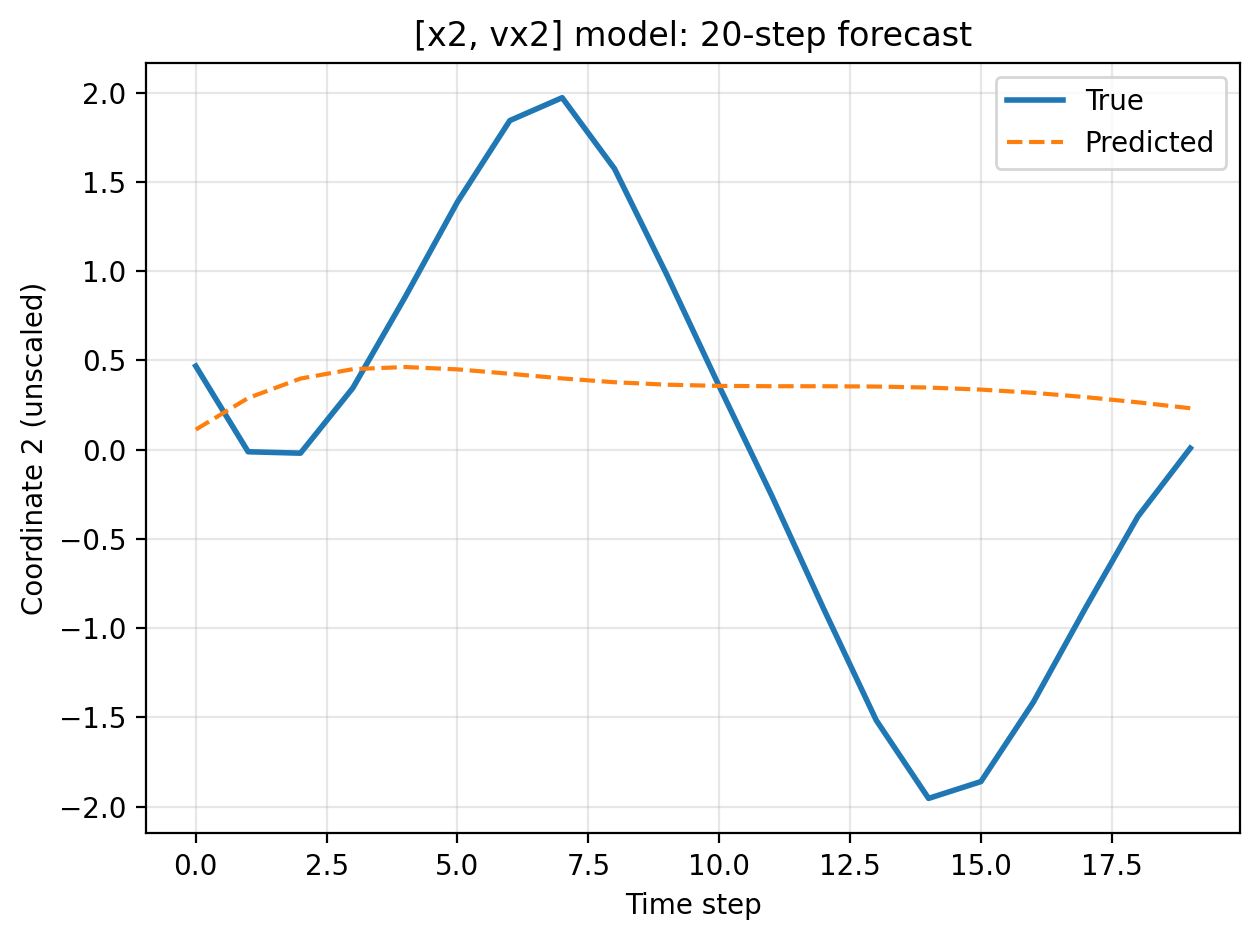

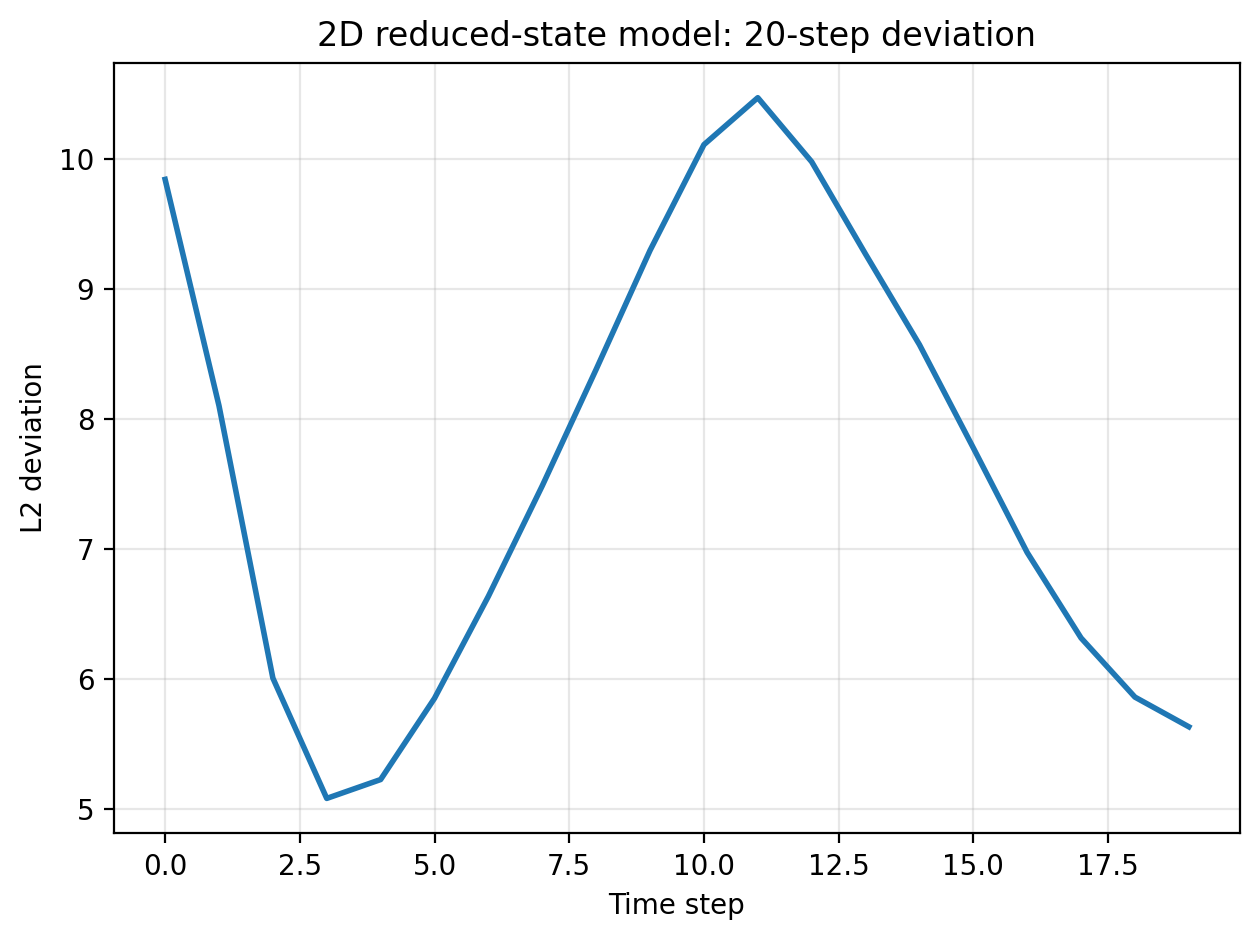

In [ ]:
coord_idx = 2   # x2 for visualisation

# True sequence for comparison (last 20 steps of test target)
true_20 = Y_test[-20:]

plot_forecast(true_20, pred_x2_20,  coord_idx, "x2-only model: 20-step forecast")
plot_deviation(true_20, pred_x2_20, "x2-only model: 20-step deviation")

plot_forecast(true_20, pred_vx2_20, coord_idx, "vx2-only model: 20-step forecast")
plot_deviation(true_20, pred_vx2_20, "vx2-only model: 20-step deviation")

plot_forecast(true_20, pred_2d_20,  coord_idx, "[x2, vx2] model: 20-step forecast")
plot_deviation(true_20, pred_2d_20, "2D reduced-state model: 20-step deviation")


**Long-Horizon (100-step) Plots :**

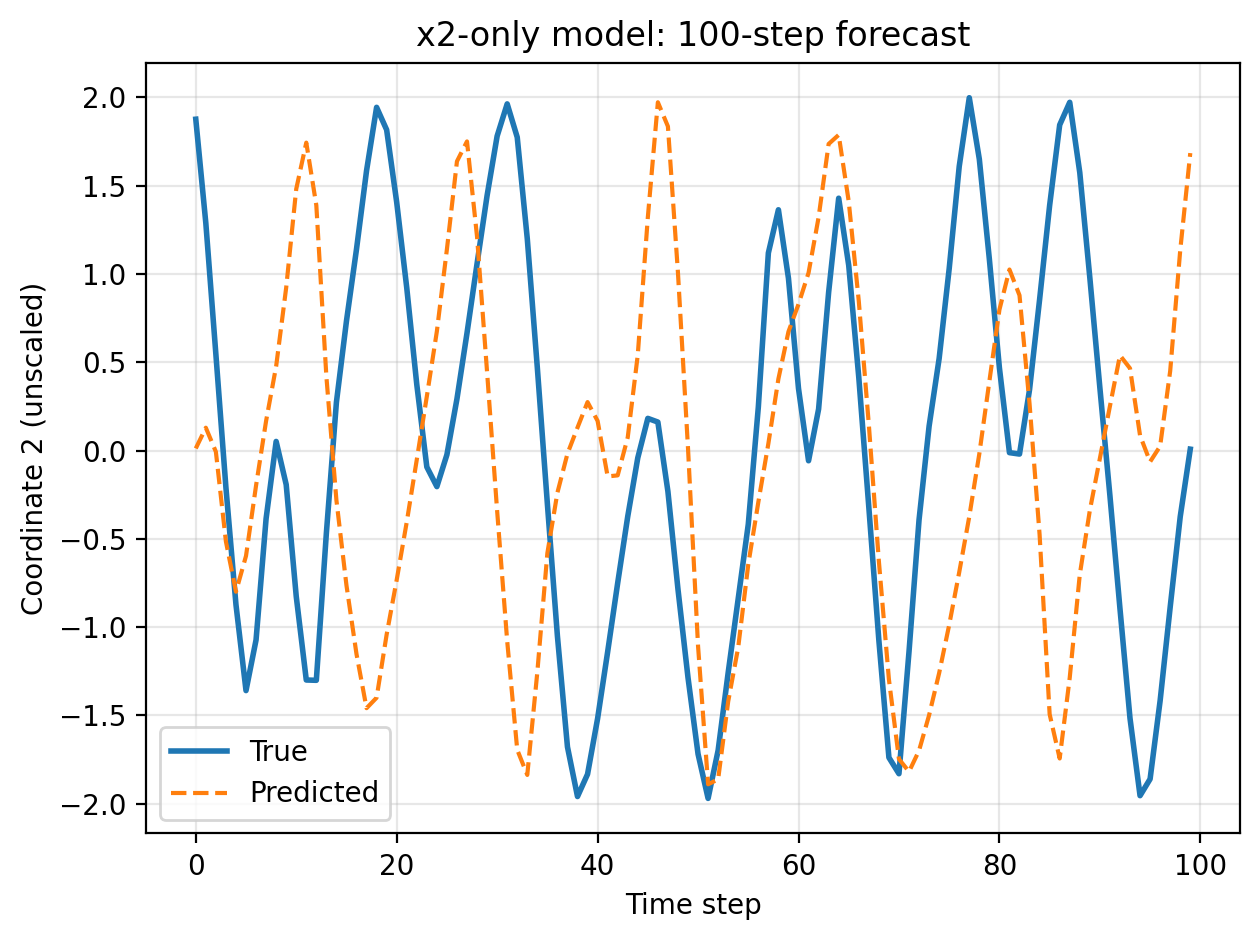

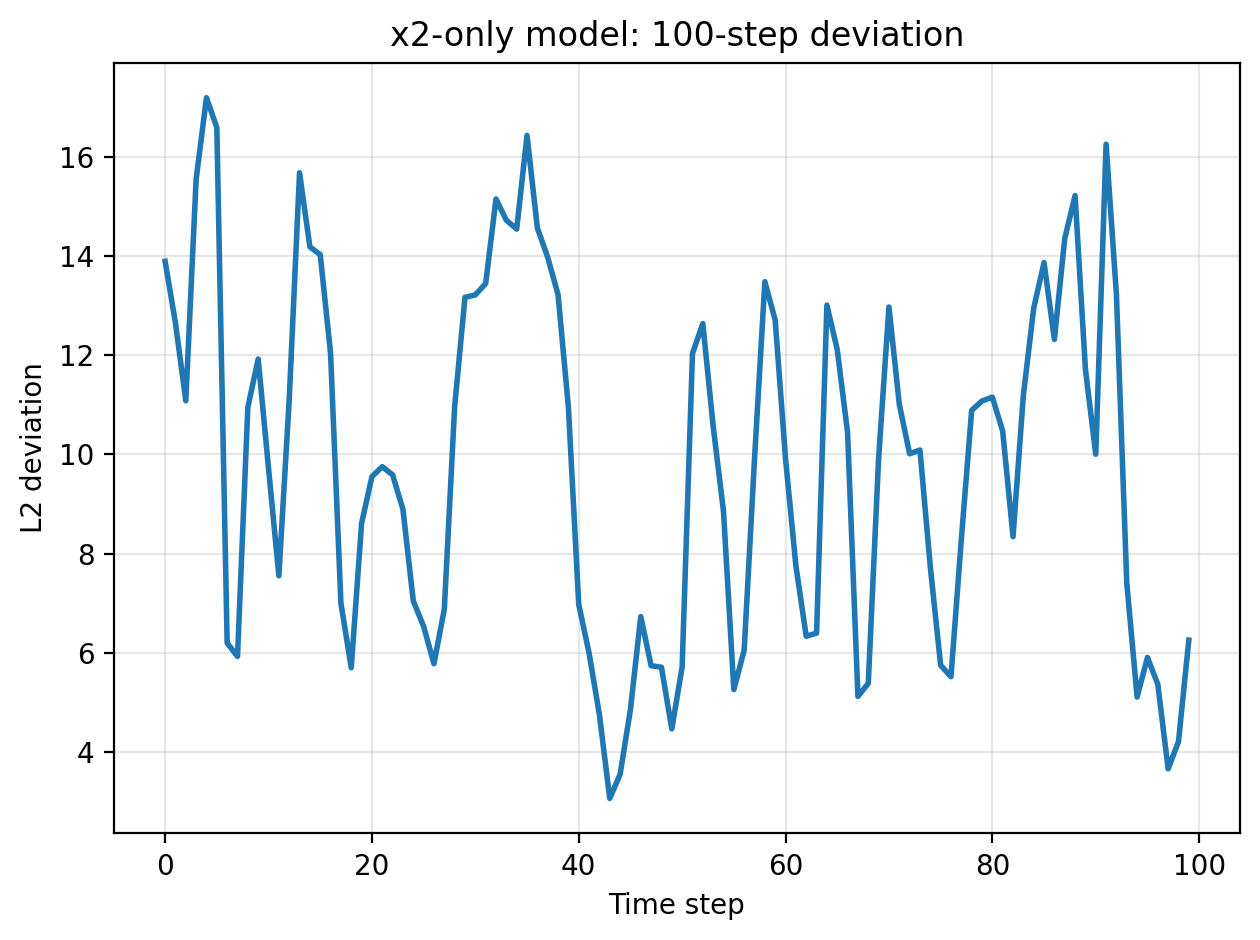

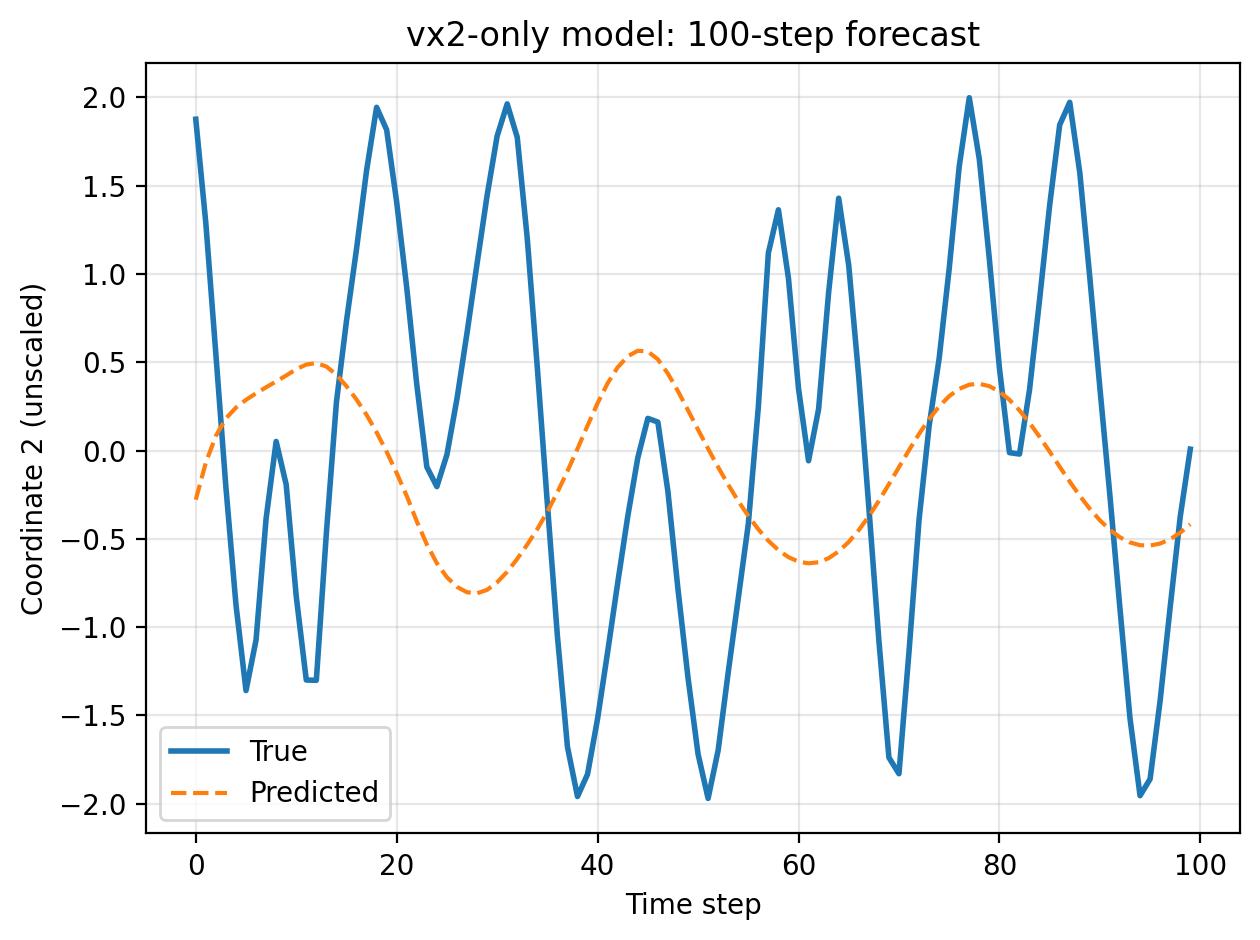

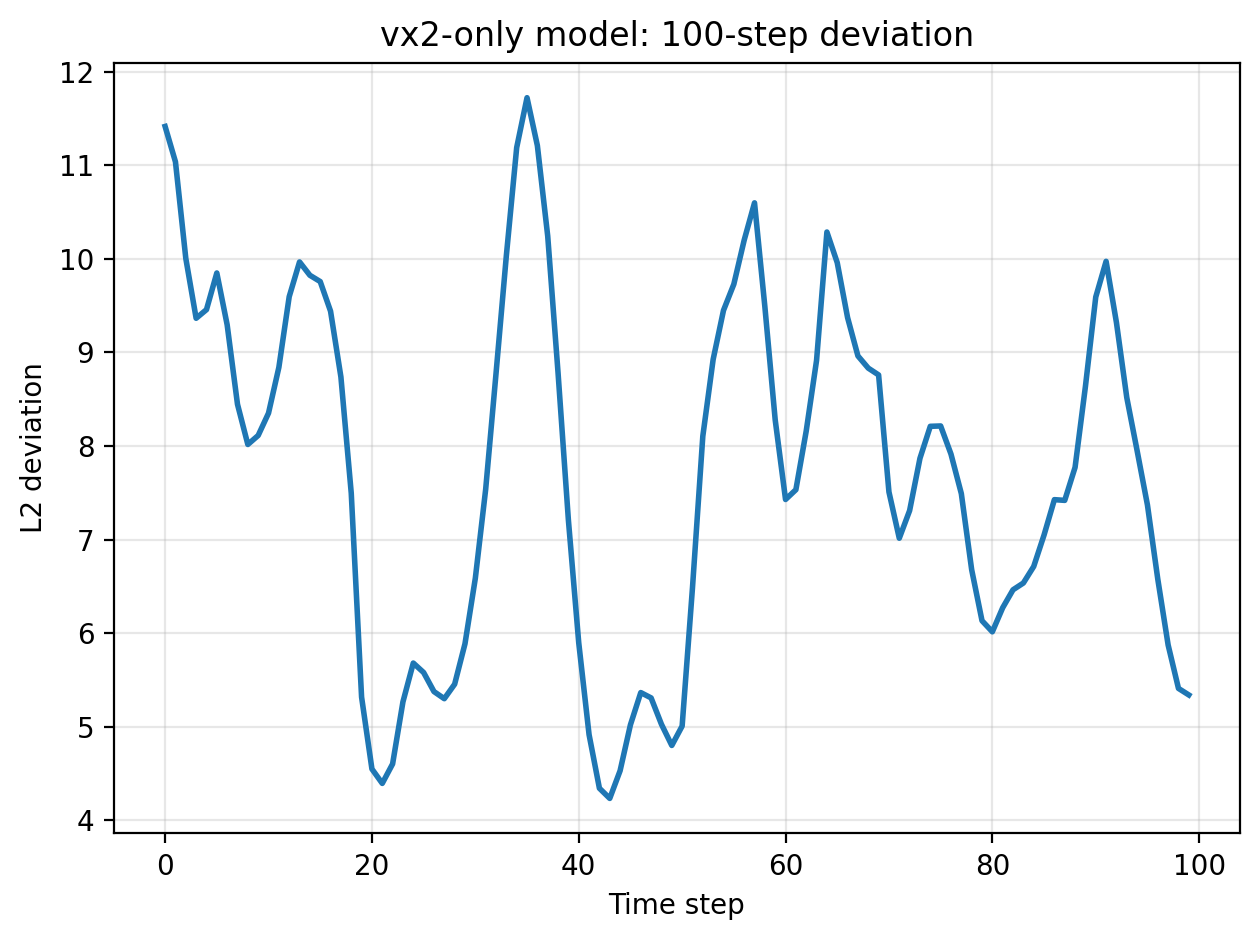

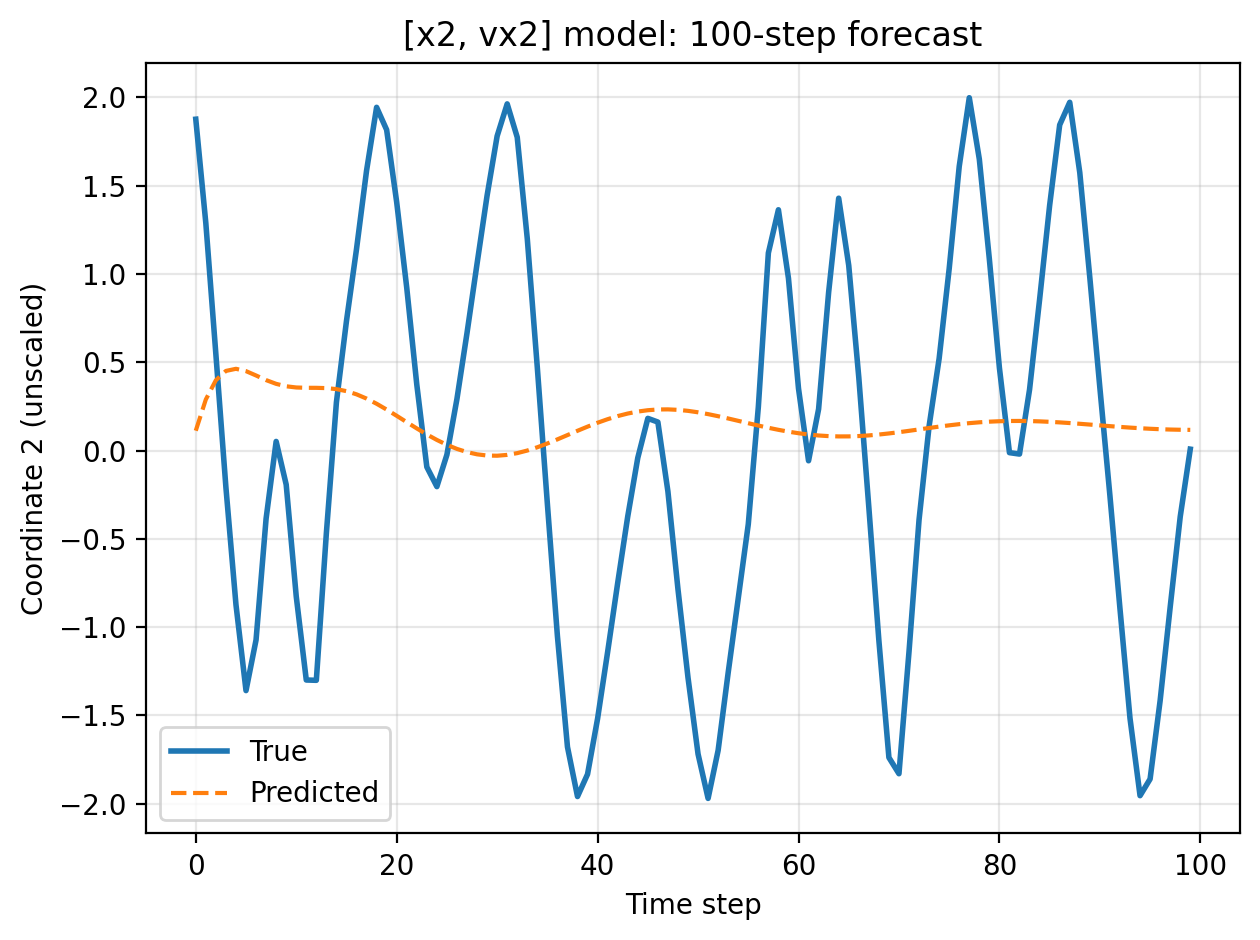

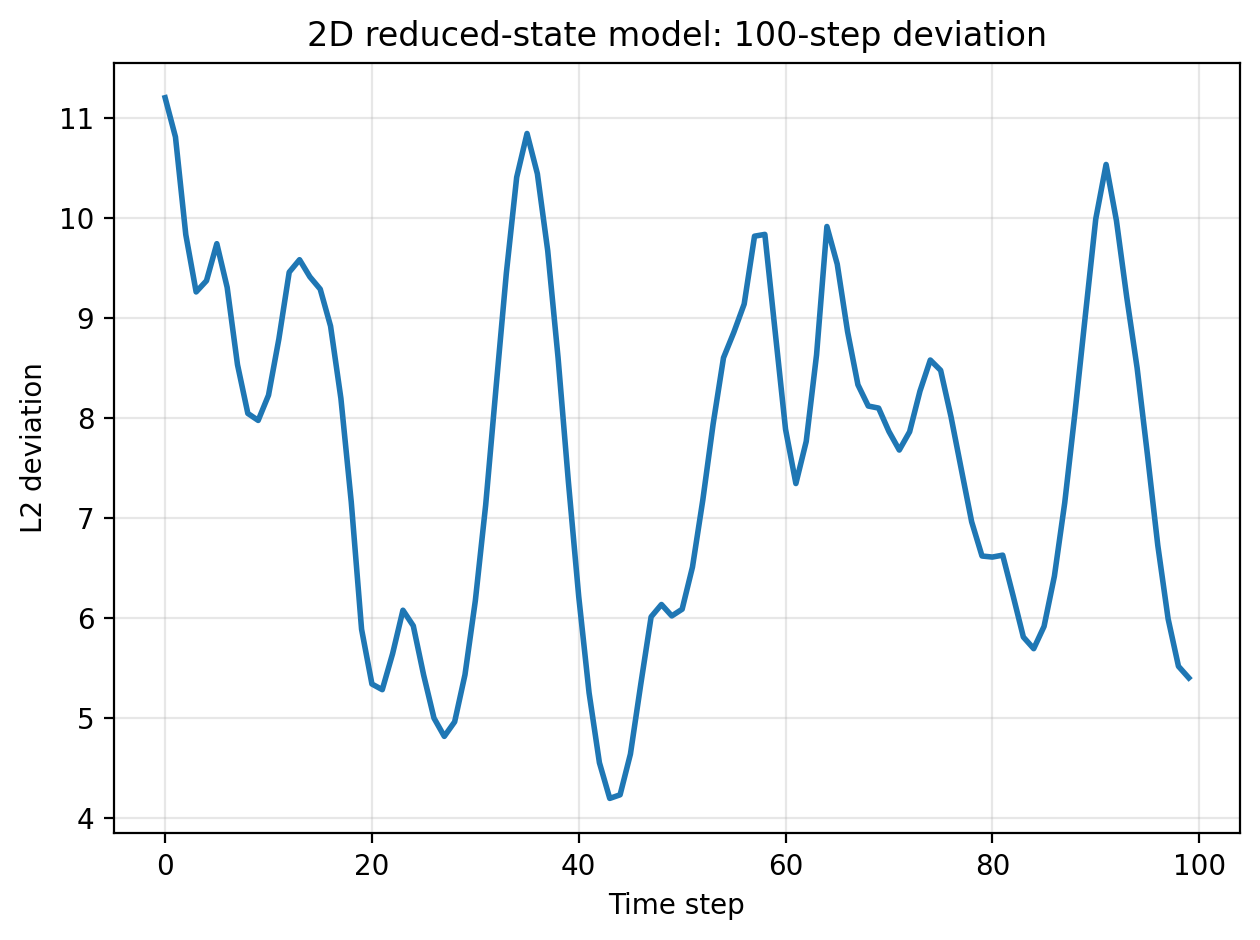

In [ ]:
true_100 = Y_test[-100:]

plot_forecast(true_100, pred_x2_100,  coord_idx, "x2-only model: 100-step forecast")
plot_deviation(true_100, pred_x2_100, "x2-only model: 100-step deviation")

plot_forecast(true_100, pred_vx2_100, coord_idx, "vx2-only model: 100-step forecast")
plot_deviation(true_100, pred_vx2_100, "vx2-only model: 100-step deviation")

plot_forecast(true_100, pred_2d_100,  coord_idx, "[x2, vx2] model: 100-step forecast")
plot_deviation(true_100, pred_2d_100, "2D reduced-state model: 100-step deviation")


The reduced‑order forecasting experiments demonstrate that the dominant observables x2 and vx2 retain a surprising amount of predictive structure despite the system’s chaotic dynamics. Individually, each coordinate supports short‑horizon reconstruction of the full state, but diverges rapidly over longer horizons. In contrast, the 2‑D reduced state [x2, vx2] yields markedly more stable rollouts and slower deviation growth, recovering a substantial fraction of the full‑state model’s forecasting capability. These results highlight the value of data‑driven coordinate selection and show that a minimal set of physically meaningful observables can support non‑trivial forecasting of an eight‑dimensional chaotic system.

**Test-Set Evaluation ( mae = loss ) :**

In [ ]:
test_mae_x2  = model_x2.evaluate(Xx_test, Y_test, verbose=0)
test_mae_vx2 = model_vx2.evaluate(Xv_test, Y_test, verbose=0)
test_mae_2d  = model_2d.evaluate(X2_test, Y_test, verbose=0)

print(f"x2-only model   → MAE: {test_mae_x2:.4f}")
print(f"vx2-only model  → MAE: {test_mae_vx2:.4f}")
print(f"[x2, vx2] model → MAE: {test_mae_2d:.4f}")


x2-only model   → MAE: 0.1318
vx2-only model  → MAE: 0.2266
[x2, vx2] model → MAE: 0.2084


x₂ alone gives the best one-step MAE, consistent with the sensitivity ranking. vx₂ alone is the weakest, also as expected. The 2D pair sits in between on one-step error but holds together noticeably longer in the rollouts; the deviation curve stays flatter past 50 steps where the single-coordinate models have already collapsed. All three diverge substantially by 100 steps, consistent with the exponential error growth expected in a chaotic system.

# Conclusion \& Future Work

This notebook established a data-driven pipeline for identifying the most informative coordinates of the double pendulum under partial observability. PCA, t-SNE/UMAP embeddings, and one-step sensitivity analysis consistently identified x₂ and vₓ₂ as the dominant observables. Reduced-order LSTM models trained on these coordinates forecast the full 8-dimensional state, with the 2D pair [x₂, vₓ₂] exhibiting noticeably slower divergence in the rollouts than either coordinate alone. One-step MAE values for all three reduced-order models fall within the same range as the full-state baseline. All three models diverge substantially by 100 steps, consistent with the exponential error growth expected in a chaotic system.

A natural extension would be to compare these reduced-order models against a physics-informed full-state model (as in Notebook 1), to quantify whether the energy-based penalty provides a stability advantage beyond what coordinate selection alone achieves.